# Sequence-dependent cytosine deamination analysis

This notebook reproduces the numerical analysis and main data visualizations from the thesis:

**Spontaneous deamination of cytosine in DNA – modelling the impact of nucleotide sequence**

The workflow:

1. reads MED energy components from `deamination_results.csv`,
2. validates and sorts the dataset,
3. calculates **DTSS = MED_TS − MED_substrate**,
4. reproduces the MED and DTSS heatmaps and profiles,
5. compares Das and CAMM contributions,
6. identifies the most favorable nucleotide at each position,
7. summarizes the favorable local sequence context.

The CSV contains 144 observations: 2 central bases × 2 DNA forms × 9 positions × 4 neighboring nucleotides. Position −1 is excluded because it produced steric clashes in the structural models.


In [32]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display
import seaborn as sns


POSITION_ORDER = [-5, -4, -3, -2, 1, 2, 3, 4, 5]
NUCLEOTIDE_ORDER = ["A", "C", "T", "G"]
CENTRAL_BASE_ORDER = ["C", "5mC"]
DNA_FORM_ORDER = ["A-DNA", "B-DNA"]

DATA_PATH = Path("deamination_results.csv")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The file thesis_results.csv was not found. "
        "Keep it in the same folder as this notebook."
    )


## 1. Load and validate the input data

In [19]:
df = pd.read_csv(DATA_PATH)

required_columns = {
    "central_base", "dna_form", "position", "nucleotide",
    "Das_substrate", "CAMM_substrate", "MED_substrate",
    "Das_TS", "CAMM_TS", "MED_TS"
}
missing = required_columns.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df["position"] = pd.to_numeric(df["position"], errors="raise").astype(int)

if df.duplicated(["central_base", "dna_form", "position", "nucleotide"]).any():
    duplicates = df.loc[
        df.duplicated(
            ["central_base", "dna_form", "position", "nucleotide"],
            keep=False
        )
    ]
    raise ValueError("Duplicate system rows detected:\n" + duplicates.to_string())

expected_rows = (
    len(CENTRAL_BASE_ORDER)
    * len(DNA_FORM_ORDER)
    * len(POSITION_ORDER)
    * len(NUCLEOTIDE_ORDER)
)
if len(df) != expected_rows:
    raise ValueError(f"Expected {expected_rows} rows, found {len(df)}.")

df["central_base"] = pd.Categorical(
    df["central_base"], categories=CENTRAL_BASE_ORDER, ordered=True
)
df["dna_form"] = pd.Categorical(
    df["dna_form"], categories=DNA_FORM_ORDER, ordered=True
)
df["position"] = pd.Categorical(
    df["position"], categories=POSITION_ORDER, ordered=True
)
df["nucleotide"] = pd.Categorical(
    df["nucleotide"], categories=NUCLEOTIDE_ORDER, ordered=True
)

df = df.sort_values(
    ["central_base", "dna_form", "position", "nucleotide"]
).reset_index(drop=True)

print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
display(df.head(12))


Loaded 144 rows and 10 columns.


,CAMM_TS,CAMM_substrate,Das_TS,Das_substrate,MED_TS,MED_substrate,central_base,dna_form,nucleotide,position
0,0.007,0.008,-0.003,-0.004,0.004,0.004,C,A-DNA,A,-5
1,-0.107,-0.152,-0.003,-0.003,-0.110,-0.155,C,A-DNA,C,-5
2,0.045,0.069,-0.003,-0.003,0.042,0.066,C,A-DNA,T,-5
3,0.202,0.289,-0.003,-0.003,0.199,0.286,C,A-DNA,G,-5
4,0.038,0.012,-0.010,-0.012,0.028,0.000,C,A-DNA,A,-4
5,-0.102,-0.216,-0.008,-0.009,-0.110,-0.225,C,A-DNA,C,-4
6,0.128,0.202,-0.008,-0.009,0.120,0.193,C,A-DNA,T,-4
7,0.315,0.517,-0.009,-0.011,0.306,0.506,C,A-DNA,G,-4
8,0.151,0.007,-0.047,-0.059,0.104,-0.052,C,A-DNA,A,-3
9,-0.076,-0.372,-0.036,-0.044,-0.112,-0.416,C,A-DNA,C,-3


## 2. Validate MED and calculate DTSS

In [20]:
# MED should equal Das + CAMM, allowing for small rounding differences.
df["MED_substrate_check"] = df["Das_substrate"] + df["CAMM_substrate"]
df["MED_TS_check"] = df["Das_TS"] + df["CAMM_TS"]

substrate_error = (
    df["MED_substrate"] - df["MED_substrate_check"]
).abs().max()
ts_error = (
    df["MED_TS"] - df["MED_TS_check"]
).abs().max()

print(f"Maximum |MED_substrate - (Das + CAMM)|: {substrate_error:.4f} kcal/mol")
print(f"Maximum |MED_TS - (Das + CAMM)|: {ts_error:.4f} kcal/mol")

# Differential transition-state stabilization
df["DTSS"] = df["MED_TS"] - df["MED_substrate"]

# Negative DTSS means preferential stabilization of the transition state.
df["DTSS_effect"] = np.select(
    [df["DTSS"] < 0, df["DTSS"] > 0],
    ["favorable", "unfavorable"],
    default="neutral"
)

display(
    df[
        [
            "central_base", "dna_form", "position", "nucleotide",
            "MED_substrate", "MED_TS", "DTSS", "DTSS_effect"
        ]
    ].head(12)
)


Maximum |MED_substrate - (Das + CAMM)|: 0.0000 kcal/mol
Maximum |MED_TS - (Das + CAMM)|: 0.0000 kcal/mol


,central_base,dna_form,position,nucleotide,MED_substrate,MED_TS,DTSS,DTSS_effect
0,C,A-DNA,-5,A,0.004,0.004,0.000,neutral
1,C,A-DNA,-5,C,-0.155,-0.110,0.045,unfavorable
2,C,A-DNA,-5,T,0.066,0.042,-0.024,favorable
3,C,A-DNA,-5,G,0.286,0.199,-0.087,favorable
4,C,A-DNA,-4,A,0.000,0.028,0.028,unfavorable
5,C,A-DNA,-4,C,-0.225,-0.110,0.115,unfavorable
6,C,A-DNA,-4,T,0.193,0.120,-0.073,favorable
7,C,A-DNA,-4,G,0.506,0.306,-0.200,favorable
8,C,A-DNA,-3,A,-0.052,0.104,0.156,unfavorable
9,C,A-DNA,-3,C,-0.416,-0.112,0.304,unfavorable


### Interpretation

- **DTSS < 0**: the neighboring nucleotide stabilizes the transition state more strongly than the substrate, so the local context is favorable for deamination.
- **DTSS > 0**: the substrate is stabilized more strongly, so the context is unfavorable for deamination.


## 3. MED interaction-energy heatmaps — thesis Fig. 5

Global MED color scale:
vmin = -10.628
vmax = 3.306


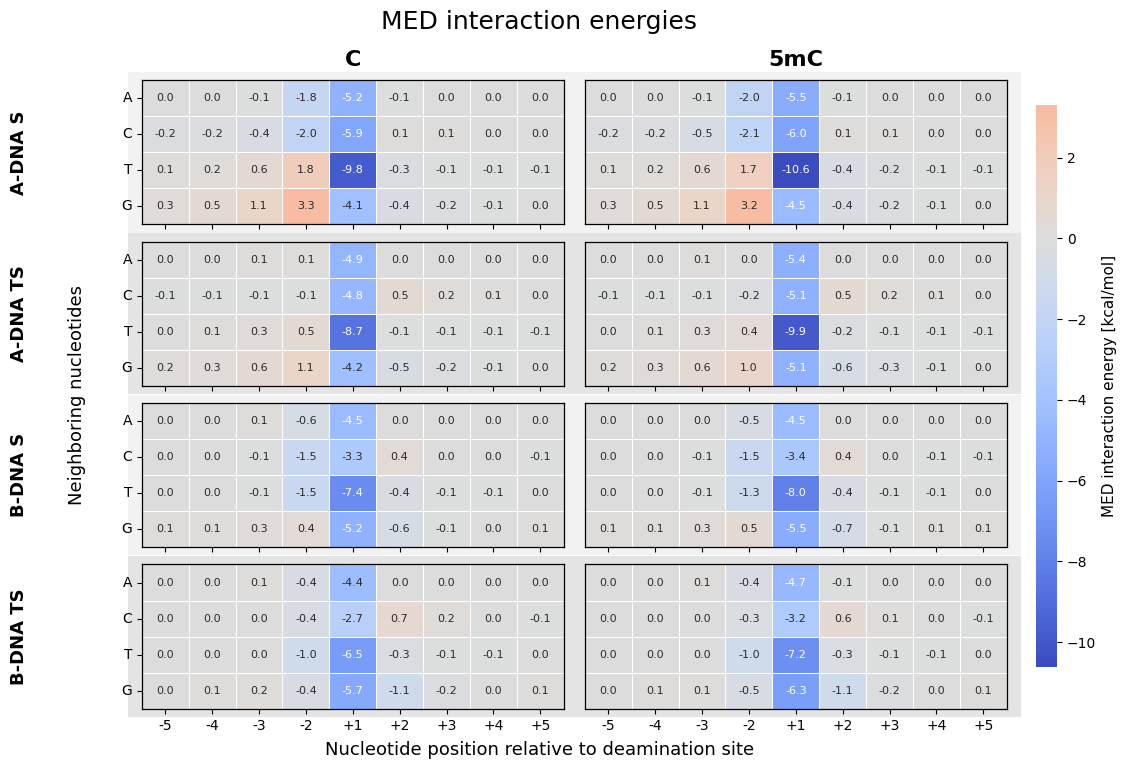

Saved PNG: figures/fig5_MED_heatmaps.png
Saved PDF: figures/fig5_MED_heatmaps.pdf


In [31]:

# ===== FUNCTION =====

def matrix_for(group, value_column):
    matrix = (
        group.pivot(index="nucleotide", columns="position", values=value_column)
        .reindex(index=NUCLEOTIDE_ORDER, columns=POSITION_ORDER)
    )
    matrix = matrix.astype(float).round(1)
    matrix = matrix.mask(matrix == -0.0, 0.0)
    return matrix


# ===== SETTINGS =====

panel_specs = [
    ("A-DNA", "substrate"),
    ("A-DNA", "TS"),
    ("B-DNA", "substrate"),
    ("B-DNA", "TS"),
]

row_labels = [
    "A-DNA S",
    "A-DNA TS",
    "B-DNA S",
    "B-DNA TS",
]

row_background_colors = {
    "substrate": "#f2f2f2",
    "TS": "#e4e4e4",
}

# etykiety osi X: -5, -4, -3, -2, +1, +2...
x_labels = [
    f"{p:+d}" if p > 0 else str(p)
    for p in POSITION_ORDER
]

# common color scale for MED substrate and MED TS
all_med_values = np.concatenate([
    df["MED_substrate"].to_numpy(dtype=float),
    df["MED_TS"].to_numpy(dtype=float)
])

global_vmin = float(np.nanmin(all_med_values))
global_vmax = float(np.nanmax(all_med_values))

print("Global MED color scale:")
print("vmin =", global_vmin)
print("vmax =", global_vmax)


# ===== CREATE FIGURE =====
# A4 landscape
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(11.69, 8.27),
    sharex=True,
    sharey=True
)

# colorbar
cbar_ax = fig.add_axes([0.925, 0.17, 0.018, 0.68])

fig.subplots_adjust(
    top=0.88,
    bottom=0.12,
    left=0.16,
    right=0.90,
    hspace=0.12,
    wspace=0.05
)


# ===== ROW BACKGROUNDS =====

fig.canvas.draw()

for row_idx, (dna_form, state) in enumerate(panel_specs):
    left_pos = axes[row_idx, 0].get_position()
    right_pos = axes[row_idx, 1].get_position()

    x0 = left_pos.x0 - 0.012
    y0 = left_pos.y0 - 0.010
    x1 = right_pos.x1 + 0.012
    y1 = left_pos.y1 + 0.010

    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        transform=fig.transFigure,
        facecolor=row_background_colors[state],
        edgecolor="none",
        zorder=-10
    )

    fig.patches.append(rect)


# ===== PLOT HEATMAPS =====

for row_idx, (dna_form, state) in enumerate(panel_specs):

    for col_idx, central_base in enumerate(CENTRAL_BASE_ORDER):

        ax = axes[row_idx, col_idx]
        ax.set_facecolor(row_background_colors[state])

        subset = df[
            (df["central_base"] == central_base)
            & (df["dna_form"] == dna_form)
        ]

        value_column = "MED_substrate" if state == "substrate" else "MED_TS"
        matrix = matrix_for(subset, value_column)

        show_cbar = (row_idx == 0 and col_idx == 1)

        sns.heatmap(
            matrix,
            annot=False,
            cmap="coolwarm",
            center=0,
            vmin=global_vmin,
            vmax=global_vmax,
            linewidths=0.5,
            linecolor="white",
            ax=ax,
            cbar=show_cbar,
            cbar_ax=cbar_ax if show_cbar else None,
            cbar_kws={"label": "MED interaction energy [kcal/mol]"}
        )

        # ręczne podpisy wartości, żeby ciemnoniebieskie pola miały biały tekst
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix.iloc[i, j]

                if np.isnan(value):
                    continue

                text_color = "white" if value <= -4.5 else "#2b2b2b"

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color
                )

        # bez tytułów pojedynczych paneli
        ax.set_title("")

        # oś X
        ax.set_xlabel("")
        ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
        ax.tick_params(axis="x", labelsize=10)

        # oś Y: litery tylko w lewej kolumnie
        ax.set_ylabel("")
        ax.set_yticklabels(NUCLEOTIDE_ORDER, rotation=0, fontsize=10)

        if col_idx == 0:
            ax.tick_params(axis="y", labelleft=True, left=True, labelsize=10)
        else:
            ax.tick_params(axis="y", labelleft=False, left=False)

        # obramowanie każdego panelu
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.9)
            spine.set_color("black")


# ===== COLORBAR =====

cbar = axes[0, 1].collections[0].colorbar

if cbar is not None:
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("MED interaction energy [kcal/mol]", fontsize=11)


# ===== COLUMN HEADERS =====

for col_idx, label in enumerate(CENTRAL_BASE_ORDER):
    pos = axes[0, col_idx].get_position()
    x = (pos.x0 + pos.x1) / 2

    fig.text(
        x,
        0.905,
        label,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold"
    )


# ===== ROW LABELS =====

for row_idx, label in enumerate(row_labels):
    pos = axes[row_idx, 0].get_position()
    y = (pos.y0 + pos.y1) / 2

    fig.text(
        0.055,
        y,
        label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=13,
        fontweight="bold"
    )


# ===== GLOBAL LABELS =====

fig.text(
    0.105,
    0.50,
    "Neighboring nucleotides",
    ha="center",
    va="center",
    rotation=90,
    fontsize=13
)

fig.text(
    0.50,
    0.07,
    "Nucleotide position relative to deamination site",
    ha="center",
    va="center",
    fontsize=13
)

fig.suptitle(
    "MED interaction energies",
    fontsize=18,
    y=0.965
)


# ===== SAVE =====

output_png = FIGURES_DIR / "fig5_MED_heatmaps.png"
output_pdf = FIGURES_DIR / "fig5_MED_heatmaps.pdf"

plt.savefig(output_png, dpi=300, bbox_inches="tight")
plt.savefig(output_pdf, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved PNG: {output_png}")
print(f"Saved PDF: {output_pdf}")

## 4. MED interaction-energy profiles — thesis Fig. 6

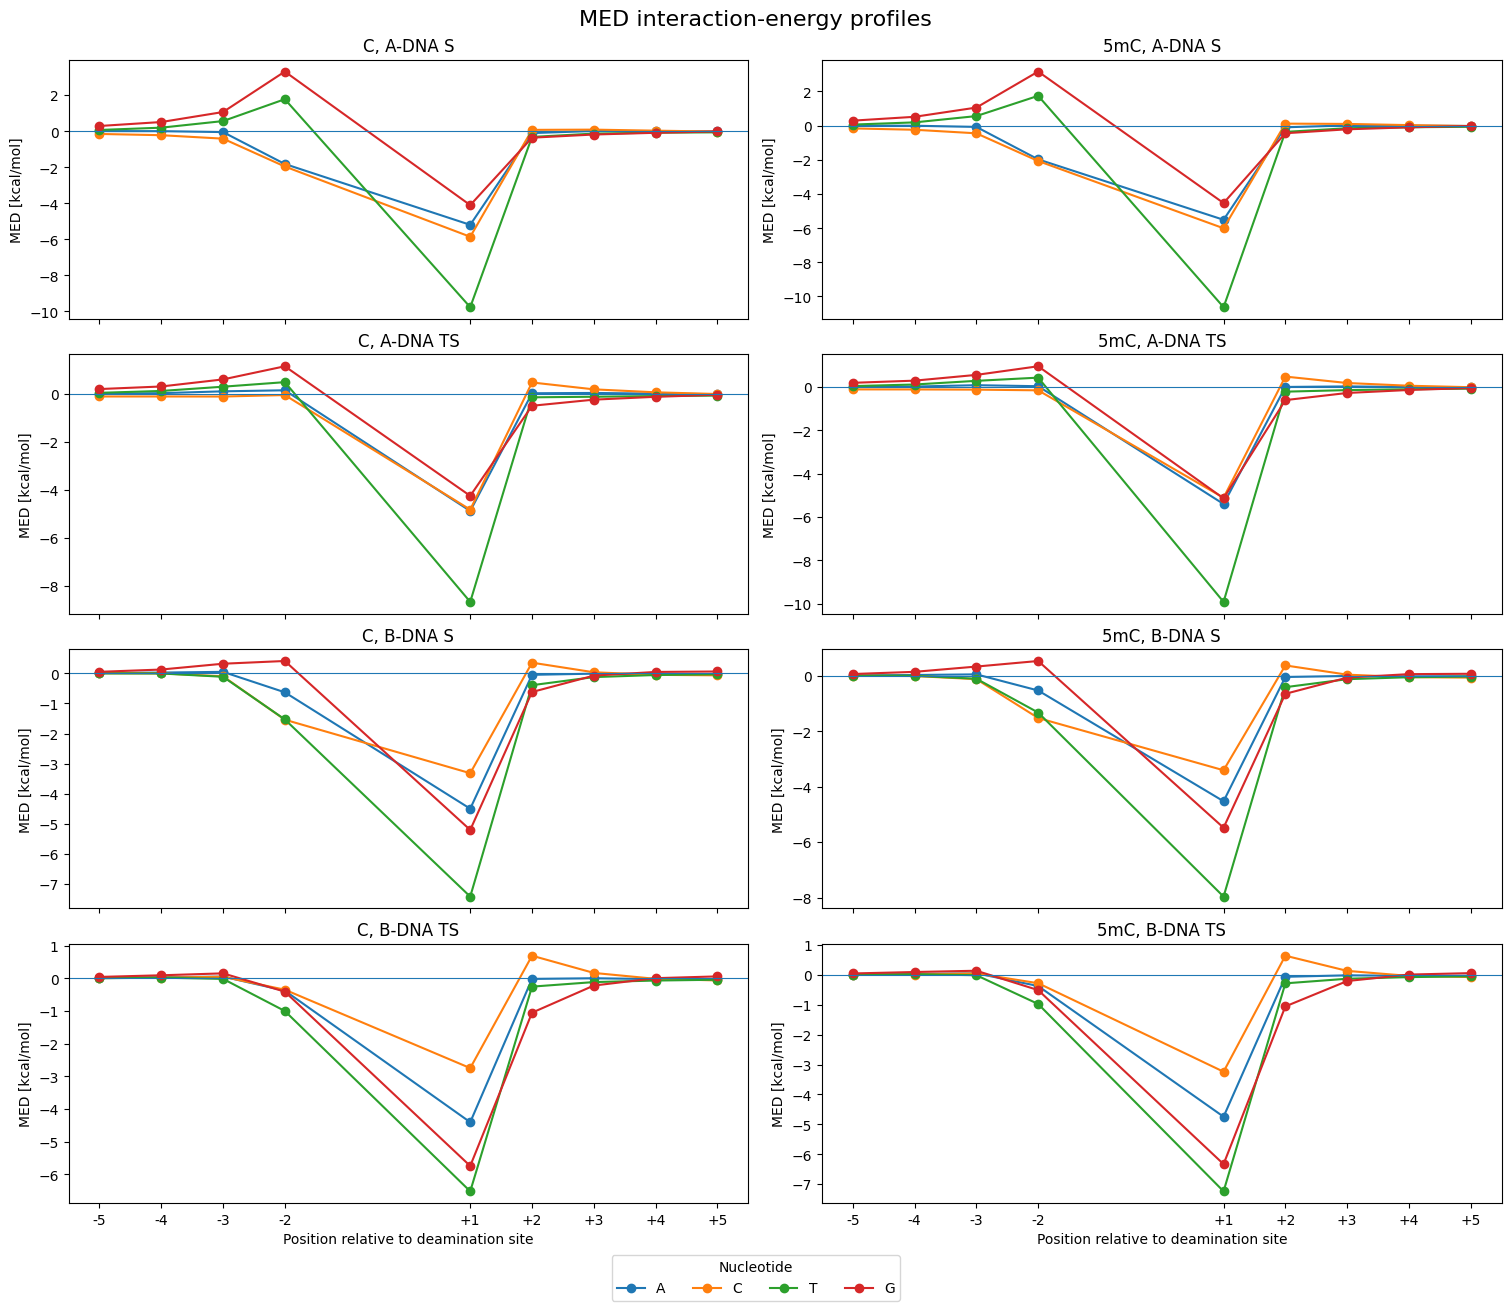

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(15, 13), sharex=True, constrained_layout=True)

for col, central_base in enumerate(CENTRAL_BASE_ORDER):
    for row, (dna_form, state) in enumerate(panel_specs):
        ax = axes[row, col]
        subset = df[
            (df["central_base"] == central_base)
            & (df["dna_form"] == dna_form)
        ]
        value_column = "MED_substrate" if state == "substrate" else "MED_TS"

        for nucleotide in NUCLEOTIDE_ORDER:
            line_data = subset[subset["nucleotide"] == nucleotide]
            line_data = line_data.sort_values("position")
            x = line_data["position"].astype(int).to_numpy()
            y = line_data[value_column].to_numpy()
            ax.plot(x, y, marker="o", label=nucleotide)

        ax.axhline(0, linewidth=0.8)
        title_state = "S" if state == "substrate" else "TS"
        ax.set_title(f"{central_base}, {dna_form} {title_state}")
        ax.set_ylabel("MED [kcal/mol]")
        ax.set_xticks(POSITION_ORDER)
        ax.set_xticklabels(
            [f"{p:+d}" if p > 0 else str(p) for p in POSITION_ORDER]
        )

for ax in axes[-1, :]:
    ax.set_xlabel("Position relative to deamination site")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Nucleotide", loc="outside lower center", ncol=4)
fig.suptitle("MED interaction-energy profiles", fontsize=16)
fig.savefig(FIGURES_DIR / "fig6_MED_profiles.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Das and CAMM contributions at the most relevant positions — thesis Fig. 7

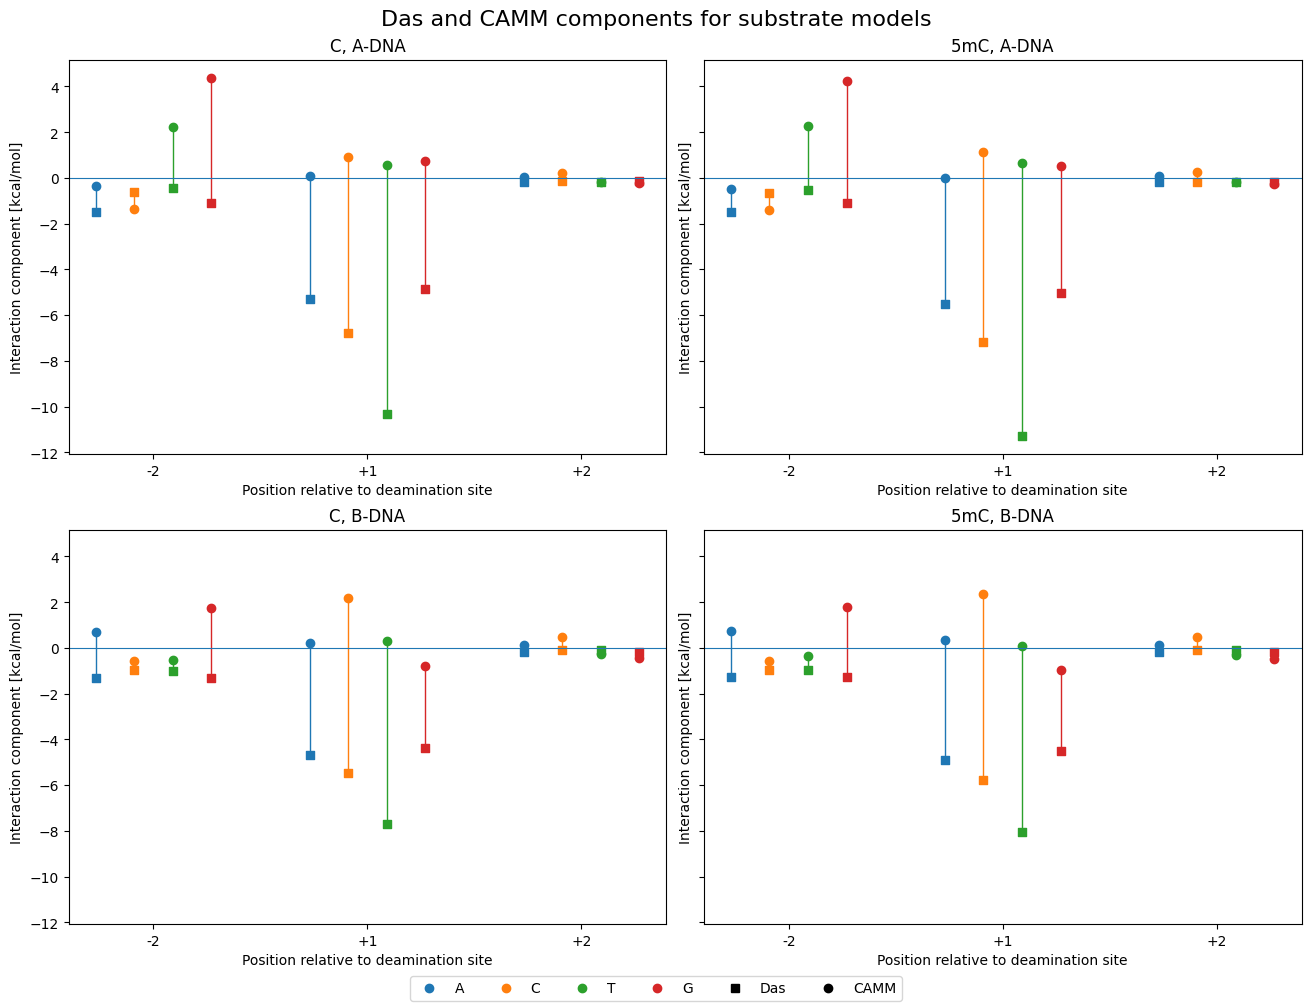

In [23]:
selected_positions = [-2, 1, 2]
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
nucleotide_colors = {
    nucleotide: default_colors[i % len(default_colors)]
    for i, nucleotide in enumerate(NUCLEOTIDE_ORDER)
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True, constrained_layout=True)

for ax, (central_base, dna_form) in zip(
    axes.flat,
    [
        ("C", "A-DNA"),
        ("5mC", "A-DNA"),
        ("C", "B-DNA"),
        ("5mC", "B-DNA"),
    ]
):
    subset = df[
        (df["central_base"] == central_base)
        & (df["dna_form"] == dna_form)
        & (df["position"].astype(int).isin(selected_positions))
    ].copy()

    offsets = np.linspace(-0.27, 0.27, len(NUCLEOTIDE_ORDER))

    for offset, nucleotide in zip(offsets, NUCLEOTIDE_ORDER):
        nuc_data = subset[subset["nucleotide"] == nucleotide].copy()
        nuc_data["position_num"] = nuc_data["position"].astype(int)
        nuc_data = nuc_data.set_index("position_num").reindex(selected_positions)

        x = np.arange(len(selected_positions)) + offset
        ax.scatter(
            x,
            nuc_data["Das_substrate"],
            marker="s",
            label=f"{nucleotide} Das",
            color=nucleotide_colors[nucleotide]
        )
        ax.scatter(
            x,
            nuc_data["CAMM_substrate"],
            marker="o",
            label=f"{nucleotide} CAMM",
            color=nucleotide_colors[nucleotide]
        )
        for xi, das_value, camm_value in zip(
            x,
            nuc_data["Das_substrate"],
            nuc_data["CAMM_substrate"]
        ):
            ax.plot(
                [xi, xi],
                [das_value, camm_value],
                color=nucleotide_colors[nucleotide],
                linewidth=1
            )

    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"{central_base}, {dna_form}")
    ax.set_xticks(range(len(selected_positions)))
    ax.set_xticklabels(["-2", "+1", "+2"])
    ax.set_xlabel("Position relative to deamination site")
    ax.set_ylabel("Interaction component [kcal/mol]")

# Compact legend: colors identify nucleotides and markers identify components.
from matplotlib.lines import Line2D

nucleotide_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        color=nucleotide_colors[nucleotide],
        label=nucleotide
    )
    for nucleotide in NUCLEOTIDE_ORDER
]
component_handles = [
    Line2D([0], [0], marker="s", linestyle="", color="black", label="Das"),
    Line2D([0], [0], marker="o", linestyle="", color="black", label="CAMM"),
]
fig.legend(
    handles=nucleotide_handles + component_handles,
    loc="outside lower center",
    ncol=6
)
fig.suptitle("Das and CAMM components for substrate models", fontsize=16)
fig.savefig(FIGURES_DIR / "fig7_Das_CAMM.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. DTSS heatmaps — thesis Fig. 8

Global DTSS color scale:
vmin = -2.2039999999999997
vmax = 2.2039999999999997


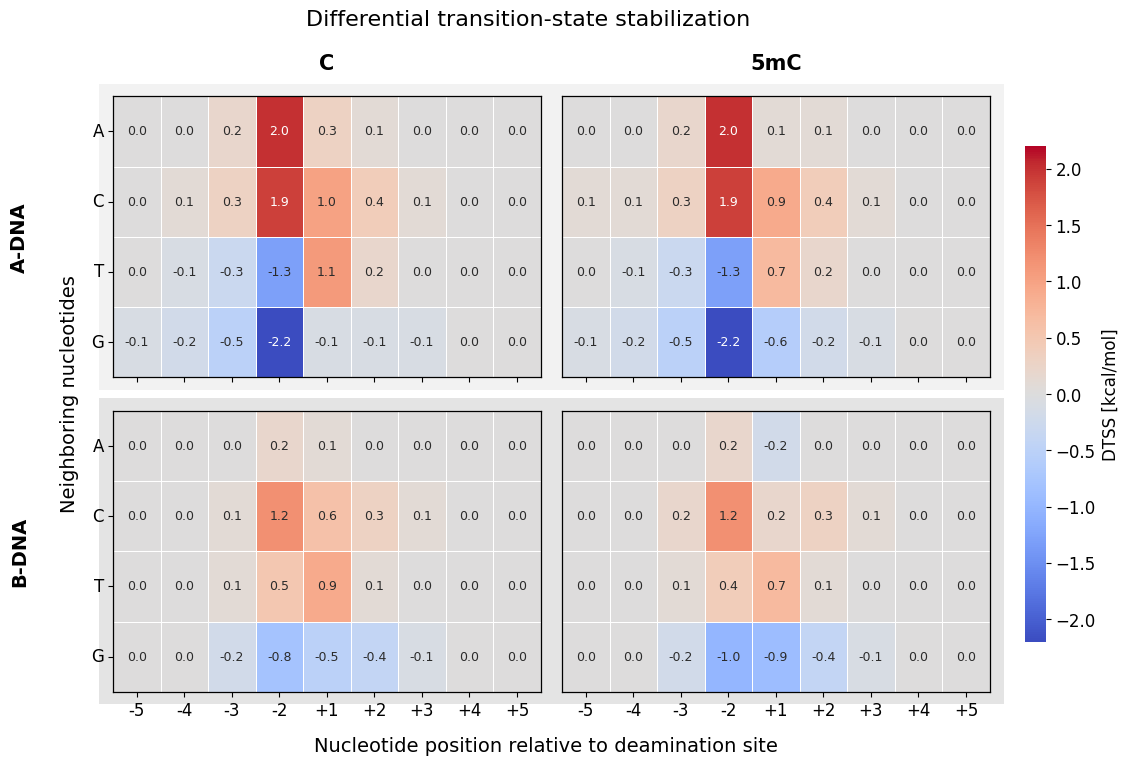

Saved PNG: figures/fig8_DTSS_heatmaps.png
Saved PDF: figures/fig8_DTSS_heatmaps.pdf


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle


# ===== FUNCTION =====

def matrix_for(group, value_column):
    matrix = (
        group.pivot(index="nucleotide", columns="position", values=value_column)
        .reindex(index=NUCLEOTIDE_ORDER, columns=POSITION_ORDER)
    )

    matrix = matrix.astype(float).round(1)
    matrix = matrix.mask(matrix == -0.0, 0.0)

    return matrix


# ===== SETTINGS =====

# Układ figury 2 x 2:
# wiersze = forma DNA
# kolumny = central base: C oraz 5mC
row_order = ["A-DNA", "B-DNA"]
column_order = CENTRAL_BASE_ORDER

row_labels = ["A-DNA", "B-DNA"]

row_background_colors = {
    "A-DNA": "#f2f2f2",
    "B-DNA": "#e4e4e4"
}

x_labels = [
    f"{p:+d}" if p > 0 else str(p)
    for p in POSITION_ORDER
]

# Rozmiary fontów
annotation_fontsize = 9
axis_number_fontsize = 12
axis_label_fontsize = 14
row_label_fontsize = 14
column_header_fontsize = 15
title_fontsize = 16
colorbar_fontsize = 12


# ===== GLOBAL COLOR SCALE =====

all_dtss = df["DTSS"].to_numpy(dtype=float)

dtss_limit = float(np.nanmax(np.abs(all_dtss)))

global_vmin = -dtss_limit
global_vmax = dtss_limit

print("Global DTSS color scale:")
print("vmin =", global_vmin)
print("vmax =", global_vmax)


# ===== CREATE FIGURE =====

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11.69, 8.27),   # A4 landscape
    sharex=True,
    sharey=False
)

# Wspólny colorbar po prawej stronie
cbar_ax = fig.add_axes([0.925, 0.20, 0.018, 0.60])

fig.subplots_adjust(
    top=0.86,
    bottom=0.14,
    left=0.145,
    right=0.895,
    hspace=0.12,
    wspace=0.05
)


# ===== ROW BACKGROUNDS =====

fig.canvas.draw()

for row_idx, dna_form in enumerate(row_order):
    left_pos = axes[row_idx, 0].get_position()
    right_pos = axes[row_idx, 1].get_position()

    x0 = left_pos.x0 - 0.012
    y0 = left_pos.y0 - 0.015
    x1 = right_pos.x1 + 0.012
    y1 = left_pos.y1 + 0.015

    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        transform=fig.transFigure,
        facecolor=row_background_colors[dna_form],
        edgecolor="none",
        zorder=-10
    )

    fig.patches.append(rect)


# ===== PLOT HEATMAPS =====

for row_idx, dna_form in enumerate(row_order):

    for col_idx, central_base in enumerate(column_order):

        ax = axes[row_idx, col_idx]
        ax.set_facecolor(row_background_colors[dna_form])

        subset = df[
            (df["central_base"] == central_base)
            & (df["dna_form"] == dna_form)
        ]

        matrix = matrix_for(subset, "DTSS")

        show_cbar = (row_idx == 0 and col_idx == 1)

        sns.heatmap(
            matrix,
            annot=False,
            cmap="coolwarm",
            center=0,
            vmin=global_vmin,
            vmax=global_vmax,
            linewidths=0.5,
            linecolor="white",
            ax=ax,
            cbar=show_cbar,
            cbar_ax=cbar_ax if show_cbar else None,
            cbar_kws={"label": "DTSS [kcal/mol]"}
        )

        # ręczne wartości w komórkach, żeby tekst był czytelny na ciemnych polach
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix.iloc[i, j]

                if np.isnan(value):
                    continue

                text_color = "white" if abs(value) >= 0.65 * dtss_limit else "#2b2b2b"

                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=annotation_fontsize,
                    color=text_color
                )

        # bez tytułów nad pojedynczymi heatmapami
        ax.set_title("")

        # oś X
        ax.set_xlabel("")
        ax.set_xticklabels(x_labels, rotation=0, fontsize=axis_number_fontsize)
        ax.tick_params(axis="x", labelsize=axis_number_fontsize)

        # oś Y tylko przy lewej kolumnie
        y_positions = [i + 0.5 for i in range(len(NUCLEOTIDE_ORDER))]
        ax.set_yticks(y_positions)

        if col_idx == 0:
            ax.set_ylabel("")
            ax.set_yticklabels(
                NUCLEOTIDE_ORDER,
                rotation=0,
                fontsize=axis_number_fontsize
            )
            ax.tick_params(
                axis="y",
                labelsize=axis_number_fontsize,
                labelleft=True,
                left=True,
                pad=3
            )
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
            ax.tick_params(axis="y", labelleft=False, left=False)

        # czarne obramowanie każdego panelu
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.9)
            spine.set_color("black")


# ===== COLORBAR FORMAT =====

cbar = axes[0, 1].collections[0].colorbar

if cbar is not None:
    cbar.ax.tick_params(labelsize=axis_number_fontsize)
    cbar.set_label("DTSS [kcal/mol]", fontsize=colorbar_fontsize)


# ===== COLUMN HEADERS =====

for col_idx, label in enumerate(column_order):
    pos = axes[0, col_idx].get_position()
    x = (pos.x0 + pos.x1) / 2

    fig.text(
        x,
        0.900,
        label,
        ha="center",
        va="center",
        fontsize=column_header_fontsize,
        fontweight="bold"
    )


# ===== ROW LABELS =====

for row_idx, label in enumerate(row_labels):
    pos = axes[row_idx, 0].get_position()
    y = (pos.y0 + pos.y1) / 2

    fig.text(
        0.065,
        y,
        label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=row_label_fontsize,
        fontweight="bold"
    )


# ===== GLOBAL Y AXIS LABEL =====

fig.text(
    0.108,
    0.50,
    "Neighboring nucleotides",
    ha="center",
    va="center",
    rotation=90,
    fontsize=axis_label_fontsize
)


# ===== GLOBAL X AXIS LABEL =====

fig.text(
    0.515,
    0.075,
    "Nucleotide position relative to deamination site",
    ha="center",
    va="center",
    fontsize=axis_label_fontsize
)


# ===== MAIN TITLE =====

fig.suptitle(
    "Differential transition-state stabilization",
    fontsize=title_fontsize,
    y=0.965
)


# ===== SAVE =====

output_png = FIGURES_DIR / "fig8_DTSS_heatmaps.png"
output_pdf = FIGURES_DIR / "fig8_DTSS_heatmaps.pdf"

plt.savefig(output_png, dpi=300, bbox_inches="tight")
plt.savefig(output_pdf, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved PNG: {output_png}")
print(f"Saved PDF: {output_pdf}")

## 7. DTSS effect diagram — thesis Fig. 9

Letter size is proportional to the absolute DTSS value. Letters above zero correspond to negative DTSS values and therefore favorable transition-state stabilization.


Logo scale factor: 0.6136363636363636
Y range: -3.0144886363636365 2.692329545454546


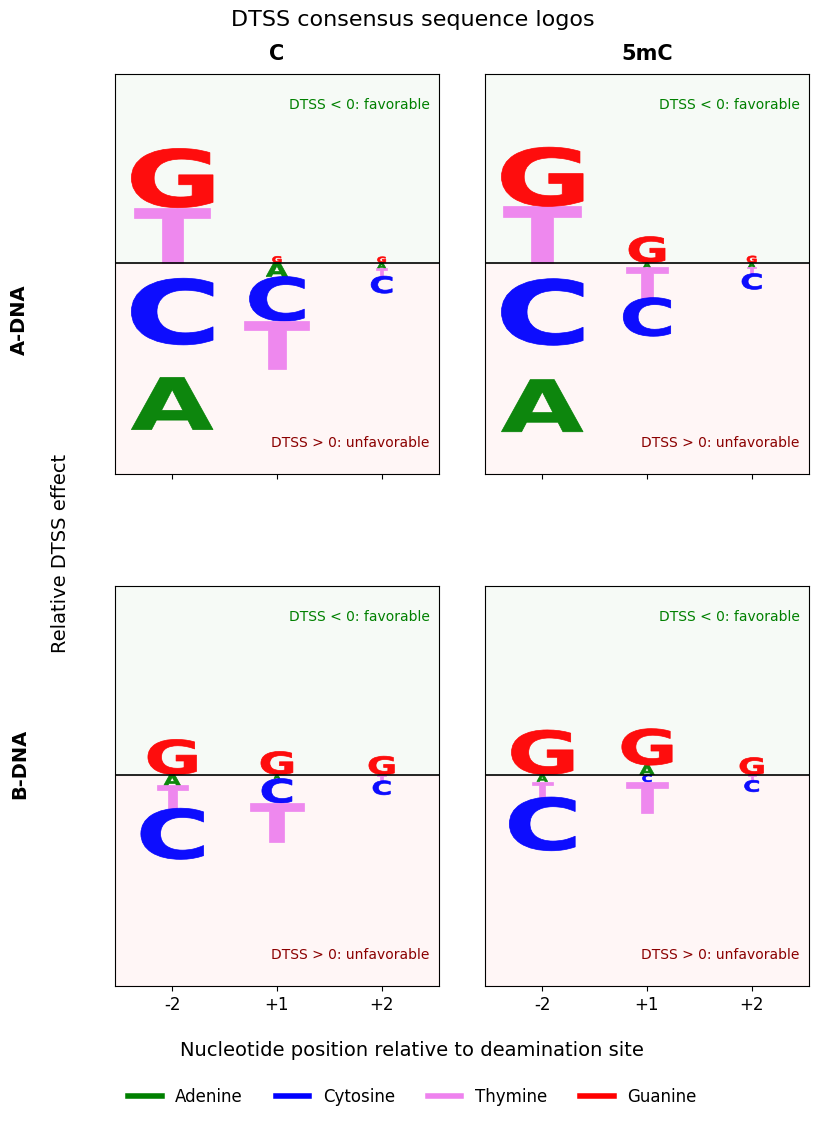

Saved PNG: figures/fig9_DTSS_consensus_sequence_logos.png
Saved PDF: figures/fig9_DTSS_consensus_sequence_logos.pdf


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties


# ============================================================
# DTSS consensus-like sequence logos
# using variables already available in the notebook
# ============================================================

# Positions shown in the logo
# These are relative positions from your df["position"] column
selected_positions = [-2, 1, 2]

# Labels shown on the x axis
relative_position_labels = {
    -2: "-2",
    1: "+1",
    2: "+2"
}

# Continuous x-axis positions without gaps
plot_position_map = {
    -2: 1,
    1: 2,
    2: 3
}

# Nucleotide order
base_order = NUCLEOTIDE_ORDER

# Colors used for nucleotide letters
base_colors = {
    "A": "green",
    "C": "blue",
    "T": "violet",
    "G": "red"
}

# Layout:
# rows = A-DNA, B-DNA
# columns = C, 5mC
row_order = ["A-DNA", "B-DNA"]
column_order = CENTRAL_BASE_ORDER

row_labels = ["A-DNA", "B-DNA"]

# Font sizes
axis_number_fontsize = 12
axis_label_fontsize = 14
row_label_fontsize = 14
column_header_fontsize = 15
legend_fontsize = 12
title_fontsize = 16

# Logo visual settings
max_stack_height = 1.35
min_draw_height = 0.03
letter_width = 0.78
letter_font = FontProperties(family="DejaVu Sans", weight="bold")


# ============================================================
# Prepare data from df
# ============================================================

def prepare_logo_data(data, central_base, dna_form):
    logo_data = data[
        (data["central_base"] == central_base)
        & (data["dna_form"] == dna_form)
        & (data["position"].isin(selected_positions))
    ][["position", "nucleotide", "DTSS"]].copy()

    logo_data = logo_data.rename(
        columns={
            "position": "Position",
            "nucleotide": "Base"
        }
    )

    logo_data["PlotPosition"] = logo_data["Position"].map(plot_position_map)
    logo_data["RelativeLabel"] = logo_data["Position"].map(relative_position_labels)

    logo_data["DTSS"] = logo_data["DTSS"].astype(float).round(2)
    logo_data.loc[logo_data["DTSS"] == -0.0, "DTSS"] = 0.0

    return logo_data


# ============================================================
# Letter drawing functions
# ============================================================

def draw_letter(ax, letter, x_center, y_bottom, height, color):
    """
    Draws one upright letter with a defined height in data units.
    The letter is centered at x_center and starts at y_bottom.
    """
    if height <= 0:
        return

    text_path = TextPath((0, 0), letter, size=1, prop=letter_font)
    bbox = text_path.get_extents()

    original_width = bbox.width
    original_height = bbox.height

    if original_width == 0 or original_height == 0:
        return

    scale_y = height / original_height
    scale_x = letter_width / original_width
    scale = min(scale_x, scale_y)

    scaled_width = original_width * scale

    x_left = x_center - scaled_width / 2
    y_shift = y_bottom

    transform = (
        Affine2D()
        .translate(-bbox.x0, -bbox.y0)
        .scale(scale, scale)
        .translate(x_left, y_shift)
        + ax.transData
    )

    patch = PathPatch(
        text_path,
        transform=transform,
        facecolor=color,
        edgecolor=color,
        linewidth=0.5,
        alpha=0.95
    )

    ax.add_patch(patch)


def draw_logo_for_position(ax, position_df, x_center, scale_factor):
    """
    DTSS < 0: favorable for reaction, drawn above baseline.
    DTSS > 0: unfavorable for reaction, drawn below baseline.
    Letters are stacked and always upright.
    """
    favorable = []
    unfavorable = []

    for base in base_order:
        row = position_df[position_df["Base"] == base]

        if row.empty:
            continue

        dtss = float(row["DTSS"].iloc[0])
        height = abs(dtss) * scale_factor

        if height < min_draw_height:
            continue

        if dtss < 0:
            favorable.append((base, height))
        elif dtss > 0:
            unfavorable.append((base, height))

    # Draw smaller letters first
    favorable = sorted(favorable, key=lambda x: x[1])
    unfavorable = sorted(unfavorable, key=lambda x: x[1])

    # Above baseline
    y = 0.0
    for base, height in favorable:
        draw_letter(ax, base, x_center, y, height, base_colors[base])
        y += height

    # Below baseline
    y = 0.0
    for base, height in unfavorable:
        y -= height
        draw_letter(ax, base, x_center, y, height, base_colors[base])


# ============================================================
# Collect data and determine scaling
# ============================================================

all_logo_data = {}
all_abs_values = []

for dna_form in row_order:
    for central_base in column_order:
        logo_data = prepare_logo_data(df, central_base, dna_form)

        all_logo_data[(central_base, dna_form)] = logo_data

        if not logo_data.empty:
            all_abs_values.extend(logo_data["DTSS"].abs().tolist())

if len(all_abs_values) == 0:
    raise ValueError("No DTSS values found for selected positions.")

max_abs_dtss = max(all_abs_values)
scale_factor = max_stack_height / max_abs_dtss

max_positive_stack = 0.0
max_negative_stack = 0.0

for logo_data in all_logo_data.values():
    for position in selected_positions:
        pos_df = logo_data[logo_data["Position"] == position]

        favorable_sum = (
            pos_df[pos_df["DTSS"] < 0]["DTSS"].abs().sum()
            * scale_factor
        )

        unfavorable_sum = (
            pos_df[pos_df["DTSS"] > 0]["DTSS"].abs().sum()
            * scale_factor
        )

        max_positive_stack = max(max_positive_stack, favorable_sum)
        max_negative_stack = max(max_negative_stack, unfavorable_sum)

ymax = max(max_positive_stack * 1.25, 1.0)
ymin = min(-max_negative_stack * 1.25, -1.0)

print("Logo scale factor:", scale_factor)
print("Y range:", ymin, ymax)


# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8.27, 11.69),
    sharex=True,
    sharey=True
)

x_ticks = [plot_position_map[pos] for pos in selected_positions]
x_tick_labels = [relative_position_labels[pos] for pos in selected_positions]


# ============================================================
# Plot logos
# ============================================================

for row_idx, dna_form in enumerate(row_order):
    for col_idx, central_base in enumerate(column_order):

        ax = axes[row_idx, col_idx]
        logo_data = all_logo_data.get((central_base, dna_form), pd.DataFrame())

        if logo_data.empty:
            ax.text(
                0.5,
                0.5,
                "Missing data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12
            )
            continue

        # Baseline
        ax.axhline(0, color="black", linewidth=1.2)

        # Light background regions
        ax.axhspan(0, ymax, color="green", alpha=0.035, zorder=0)
        ax.axhspan(ymin, 0, color="red", alpha=0.035, zorder=0)

        # Draw letters for each selected position
        for position in selected_positions:
            pos_df = logo_data[logo_data["Position"] == position]
            x_center = plot_position_map[position]
            draw_logo_for_position(ax, pos_df, x_center, scale_factor)

        # Column titles
        if row_idx == 0:
            ax.set_title(
                central_base,
                fontsize=column_header_fontsize,
                fontweight="bold",
                pad=10
            )

        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, fontsize=axis_number_fontsize)

        ax.set_xlim(0.45, len(selected_positions) + 0.55)
        ax.set_ylim(ymin, ymax)

        # Hide numeric Y-axis values
        ax.set_yticklabels([])
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.tick_params(axis="x", labelsize=axis_number_fontsize)

        ax.grid(False)

        ax.text(
            0.97,
            0.94,
            "DTSS < 0: favorable",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            color="green"
        )

        ax.text(
            0.97,
            0.06,
            "DTSS > 0: unfavorable",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=10,
            color="darkred"
        )


# ============================================================
# Global labels
# ============================================================

fig.text(
    0.50,
    0.075,
    "Nucleotide position relative to deamination site",
    ha="center",
    va="center",
    fontsize=axis_label_fontsize
)

fig.text(
    0.075,
    0.50,
    "Relative DTSS effect",
    ha="center",
    va="center",
    rotation=90,
    fontsize=axis_label_fontsize
)


# ============================================================
# Row labels
# ============================================================

row_y_positions = [0.70, 0.32]

for label, y in zip(row_labels, row_y_positions):
    fig.text(
        0.025,
        y,
        label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=row_label_fontsize,
        fontweight="bold"
    )


# ============================================================
# Legend
# ============================================================

legend_handles = []

legend_labels = {
    "A": "Adenine",
    "C": "Cytosine",
    "T": "Thymine",
    "G": "Guanine"
}

for base in base_order:
    handle = plt.Line2D(
        [0],
        [0],
        color=base_colors[base],
        linewidth=4,
        label=legend_labels.get(base, base)
    )
    legend_handles.append(handle)

fig.legend(
    legend_handles,
    [legend_labels.get(base, base) for base in base_order],
    loc="lower center",
    ncol=4,
    fontsize=legend_fontsize,
    frameon=False,
    bbox_to_anchor=(0.5, 0.015)
)


# ============================================================
# Title and spacing
# ============================================================

fig.suptitle(
    "DTSS consensus sequence logos",
    fontsize=title_fontsize,
    y=0.965
)

fig.subplots_adjust(
    top=0.91,
    bottom=0.13,
    left=0.14,
    right=0.98,
    hspace=0.28,
    wspace=0.14
)


# ============================================================
# Save
# ============================================================

output_png = FIGURES_DIR / "fig9_DTSS_consensus_sequence_logos.png"
output_pdf = FIGURES_DIR / "fig9_DTSS_consensus_sequence_logos.pdf"

plt.savefig(output_png, dpi=300, bbox_inches="tight")
plt.savefig(output_pdf, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved PNG: {output_png}")
print(f"Saved PDF: {output_pdf}")

## 8. Identify the most favorable nucleotide at each position

In [26]:
analysis_positions = [-3, -2, 1, 2]

local_df = df[df["position"].astype(int).isin(analysis_positions)].copy()

best_by_position = (
    local_df.loc[
        local_df.groupby(
            ["central_base", "dna_form", "position"],
            observed=True
        )["DTSS"].idxmin()
    ]
    [
        ["central_base", "dna_form", "position", "nucleotide", "DTSS"]
    ]
    .sort_values(["central_base", "dna_form", "position"])
    .reset_index(drop=True)
)

best_by_position["position"] = best_by_position["position"].astype(int)
best_by_position["position_label"] = best_by_position["position"].map(
    lambda p: f"{p:+d}" if p > 0 else str(p)
)

display(best_by_position)

most_favorable_overall = df.loc[df["DTSS"].idxmin()]
print(
    "Most favorable individual nucleotide context:\n"
    f"  central base: {most_favorable_overall['central_base']}\n"
    f"  DNA form: {most_favorable_overall['dna_form']}\n"
    f"  position: {int(most_favorable_overall['position']):+d}\n"
    f"  nucleotide: {most_favorable_overall['nucleotide']}\n"
    f"  DTSS: {most_favorable_overall['DTSS']:.3f} kcal/mol"
)


,central_base,dna_form,position,nucleotide,DTSS,position_label
0,C,A-DNA,-3,G,-0.460,-3
1,C,A-DNA,-2,G,-2.158,-2
2,C,A-DNA,1,G,-0.146,+1
3,C,A-DNA,2,G,-0.135,+2
4,C,B-DNA,-3,G,-0.171,-3
5,C,B-DNA,-2,G,-0.822,-2
6,C,B-DNA,1,G,-0.540,+1
7,C,B-DNA,2,G,-0.434,+2
8,5mC,A-DNA,-3,G,-0.494,-3
9,5mC,A-DNA,-2,G,-2.204,-2


Most favorable individual nucleotide context:
  central base: 5mC
  DNA form: A-DNA
  position: -2
  nucleotide: G
  DTSS: -2.204 kcal/mol


## 9. Favorable local sequence and total DTSS — quantitative equivalent of thesis Fig. 10

,central_base,dna_form,favorable_sequence,total_DTSS
0,C,A-DNA,GGGG,-2.899
1,C,B-DNA,GGGG,-1.967
2,5mC,A-DNA,GGGG,-3.464
3,5mC,B-DNA,GGGG,-2.474


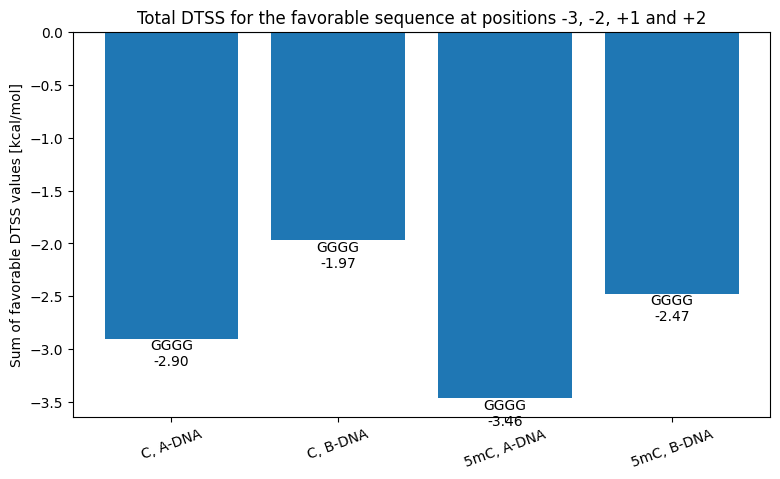

In [36]:
def format_position(position):
    return f"{int(position):+d}" if int(position) > 0 else str(int(position))


def format_position_list(positions):
    labels = [format_position(p) for p in positions]

    if len(labels) == 1:
        return labels[0]

    if len(labels) == 2:
        return " and ".join(labels)

    return ", ".join(labels[:-1]) + " and " + labels[-1]


# Positions used in the favorable sequence analysis
positions_used = (
    best_by_position["position"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

# Keep the order from POSITION_ORDER, if this constant exists in the notebook
positions_used = [p for p in POSITION_ORDER if p in positions_used]

positions_text = format_position_list(positions_used)


sequence_summary = (
    best_by_position
    .sort_values(["central_base", "dna_form", "position"])
    .groupby(["central_base", "dna_form"], observed=True)
    .agg(
        favorable_sequence=("nucleotide", "".join),
        total_DTSS=("DTSS", "sum")
    )
    .reset_index()
)

display(sequence_summary)

fig, ax = plt.subplots(figsize=(9, 5))

labels = (
    sequence_summary["central_base"].astype(str)
    + ", "
    + sequence_summary["dna_form"].astype(str)
)

ax.bar(labels, sequence_summary["total_DTSS"])
ax.axhline(0, linewidth=0.8)

ax.set_ylabel("Sum of favorable DTSS values [kcal/mol]")

ax.set_title(
    f"Total DTSS for the favorable sequence at positions {positions_text}"
)

ax.tick_params(axis="x", rotation=20)

for index, row in sequence_summary.iterrows():
    ax.text(
        index,
        row["total_DTSS"],
        f"{row['favorable_sequence']}\n{row['total_DTSS']:.2f}",
        ha="center",
        va="top" if row["total_DTSS"] < 0 else "bottom"
    )

fig.savefig(
    FIGURES_DIR / "fig10_favorable_sequence_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Automatic summary of the main results

In [37]:
def format_position(position):
    position = int(position)
    return f"{position:+d}" if position > 0 else str(position)


def format_position_list(positions):
    labels = [format_position(p) for p in positions]

    if len(labels) == 1:
        return labels[0]

    if len(labels) == 2:
        return " and ".join(labels)

    return ", ".join(labels[:-1]) + " and " + labels[-1]


# Positions used in best_by_position
positions_used = (
    best_by_position["position"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

# Keep the order from POSITION_ORDER
positions_used = [p for p in POSITION_ORDER if p in positions_used]
positions_text = format_position_list(positions_used)


# Create sequence summary, if it was not already created above
sequence_summary = (
    best_by_position
    .sort_values(["central_base", "dna_form", "position"])
    .groupby(["central_base", "dna_form"], observed=True)
    .agg(
        favorable_sequence=("nucleotide", "".join),
        total_DTSS=("DTSS", "sum")
    )
    .reset_index()
)


# Strongest global effects
strongest_med = df.loc[df["MED_substrate"].astype(float).idxmin()]
strongest_dtss = df.loc[df["DTSS"].astype(float).idxmin()]


# Most frequent favorable nucleotide in best_by_position
nucleotide_counts = best_by_position["nucleotide"].value_counts()
dominant_nucleotide = nucleotide_counts.idxmax()
dominant_nucleotide_count = int(nucleotide_counts.max())
total_favorable_choices = int(nucleotide_counts.sum())


# Most frequent favorable nucleotide per position
position_nucleotide_summary = (
    best_by_position
    .groupby(["position", "nucleotide"], observed=True)
    .size()
    .reset_index(name="count")
    .sort_values(["position", "count"], ascending=[True, False])
)

best_nucleotide_by_position = (
    position_nucleotide_summary
    .drop_duplicates("position")
    .sort_values("position")
)


# Check whether one nucleotide dominates all analyzed choices
all_same_nucleotide = dominant_nucleotide_count == total_favorable_choices

# Check whether the same nucleotide is selected at every analyzed position
dominant_positions = (
    best_nucleotide_by_position["nucleotide"]
    .eq(dominant_nucleotide)
    .all()
)


print("MAIN RESULTS")
print("=" * 60)

print(
    "Strongest substrate MED interaction: "
    f"{strongest_med['central_base']}, {strongest_med['dna_form']}, "
    f"position {format_position(strongest_med['position'])}, "
    f"{strongest_med['nucleotide']}, "
    f"MED = {strongest_med['MED_substrate']:.3f} kcal/mol"
)

print(
    "Most favorable DTSS context: "
    f"{strongest_dtss['central_base']}, {strongest_dtss['dna_form']}, "
    f"position {format_position(strongest_dtss['position'])}, "
    f"{strongest_dtss['nucleotide']}, "
    f"DTSS = {strongest_dtss['DTSS']:.3f} kcal/mol"
)

print("\nFavorable sequence summary:")
for _, row in sequence_summary.iterrows():
    print(
        f"{row['central_base']} {row['dna_form']}: "
        f"favorable sequence {row['favorable_sequence']} "
        f"with ΣDTSS = {row['total_DTSS']:.3f} kcal/mol"
    )


print("\nFavorable nucleotide by position:")
for _, row in best_nucleotide_by_position.iterrows():
    print(
        f"Position {format_position(row['position'])}: "
        f"{row['nucleotide']} selected most often "
        f"({int(row['count'])} time(s))"
    )


print("\nInterpretation:")

if all_same_nucleotide:
    print(
        f"The most favorable nucleotide is {dominant_nucleotide}. "
        f"Across positions {positions_text}, {dominant_nucleotide} is selected "
        f"as the most favorable nucleotide in every analyzed system."
    )
else:
    print(
        f"The most frequently selected favorable nucleotide is {dominant_nucleotide} "
        f"({dominant_nucleotide_count}/{total_favorable_choices} selections). "
        f"The favorable sequence pattern across positions {positions_text} is therefore "
        f"not fully uniform across all analyzed systems."
    )

print(
    f"The strongest DTSS effect occurs for {strongest_dtss['nucleotide']} "
    f"at position {format_position(strongest_dtss['position'])} "
    f"in {strongest_dtss['central_base']} {strongest_dtss['dna_form']}, "
    f"with DTSS = {strongest_dtss['DTSS']:.3f} kcal/mol."
)

print(
    f"The strongest substrate MED interaction occurs for {strongest_med['nucleotide']} "
    f"at position {format_position(strongest_med['position'])} "
    f"in {strongest_med['central_base']} {strongest_med['dna_form']}, "
    f"with MED = {strongest_med['MED_substrate']:.3f} kcal/mol."
)

MAIN RESULTS
Strongest substrate MED interaction: 5mC, A-DNA, position +1, T, MED = -10.628 kcal/mol
Most favorable DTSS context: 5mC, A-DNA, position -2, G, DTSS = -2.204 kcal/mol

Favorable sequence summary:
C A-DNA: favorable sequence GGGG with ΣDTSS = -2.899 kcal/mol
C B-DNA: favorable sequence GGGG with ΣDTSS = -1.967 kcal/mol
5mC A-DNA: favorable sequence GGGG with ΣDTSS = -3.464 kcal/mol
5mC B-DNA: favorable sequence GGGG with ΣDTSS = -2.474 kcal/mol

Favorable nucleotide by position:
Position -3: G selected most often (4 time(s))
Position -2: G selected most often (4 time(s))
Position +1: G selected most often (4 time(s))
Position +2: G selected most often (4 time(s))

Interpretation:
The most favorable nucleotide is G. Across positions -3, -2, +1 and +2, G is selected as the most favorable nucleotide in every analyzed system.
The strongest DTSS effect occurs for G at position -2 in 5mC A-DNA, with DTSS = -2.204 kcal/mol.
The strongest substrate MED interaction occurs for T at 

## 11. Export processed results

In [29]:
processed_path = Path("thesis_results_with_DTSS.csv")
summary_path = Path("favorable_nucleotides.csv")

export_df = df.copy()
for column in ["central_base", "dna_form", "position", "nucleotide"]:
    export_df[column] = export_df[column].astype(str)

numeric_columns = export_df.select_dtypes(include="number").columns
export_df[numeric_columns] = export_df[numeric_columns].round(3)

summary_export = best_by_position.copy()
summary_export["DTSS"] = summary_export["DTSS"].round(3)

export_df.drop(
    columns=["MED_substrate_check", "MED_TS_check"]
).to_csv(processed_path, index=False)

summary_export.to_csv(summary_path, index=False)

print(f"Saved processed data to: {processed_path.resolve()}")
print(f"Saved favorable nucleotide summary to: {summary_path.resolve()}")
print(f"Saved figures to: {FIGURES_DIR.resolve()}")

Saved processed data to: /home/gabi/Downloads/Send Anywhere (2026-07-13 07-43-47)/thesis_results_with_DTSS.csv
Saved favorable nucleotide summary to: /home/gabi/Downloads/Send Anywhere (2026-07-13 07-43-47)/favorable_nucleotides.csv
Saved figures to: /home/gabi/Downloads/Send Anywhere (2026-07-13 07-43-47)/figures


## Portfolio note

This notebook automates the **data-analysis stage** of the thesis. It does not claim to automate generation of DNA structures, preparation of GAMESS inputs or the original quantum-chemical calculations. It starts from the calculated MED components and provides a reproducible workflow for validation, DTSS calculation, visualization and identification of favorable sequence contexts.
